# KPI choropleths — Mexico City

**Author: Lorena Pérez · Phase 3 · TEAM_PLAN §4.4**

This notebook loads warehouse indicators only through `src.analysis.data.load_kpis`. It maps all 2,348 city-core AGEBs with five-quantile classes, writes one PNG per indicator to `outputs/maps/`, and assembles the six panels in `outputs/figures/kpi_choropleths_summary.png`. Per-resident rates (`pea_rate`, `crime_rate_per_1k`) are unstable for AGEBs with fewer than 100 residents, so those AGEBs are drawn in grey with AGEBs whose ratio is undefined; area densities and crimes per 100 businesses do not depend on the resident denominator and are mapped for every AGEB. The maps are descriptive rather than causal.

In [1]:
import sys
from pathlib import Path

import mapclassify
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src/analysis/data.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the repository root containing src/analysis/data.py")
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.data import load_kpis

In [2]:
kpis = load_kpis(exclude_low_population=False)
assert kpis.crs.to_epsg() == 6372, f"Expected EPSG:6372, got {kpis.crs}"

map_specs = [
    ("pop_density_km2", "Population density", "persons / km²", "pop_density_km2", "YlOrRd"),
    ("pea_rate", "Economically active population rate", "proportion (0–1)", "pea_rate", "YlGnBu"),
    ("business_density_km2", "Business density", "establishments / km²", "business_density_km2", "PuBu"),
    ("retail_density_km2", "Retail density", "establishments / km²", "retail_density_km2", "YlOrBr"),
    ("crime_rate_per_1k", "Recorded crime rate", "investigations / 1,000 residents", "crime_rate_per_1k", "OrRd"),
    ("crimes_per_100_businesses", "Crime relative to business activity", "investigations / 100 establishments", "crimes_per_100_businesses", "magma"),
]
# Rates whose denominator is residents; masked where pop_total < 100 (low_population).
per_resident_rates = {"pea_rate", "crime_rate_per_1k"}
maps_dir = PROJECT_ROOT / "outputs/maps"
figures_dir = PROJECT_ROOT / "outputs/figures"
maps_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Loaded {len(kpis):,} city-core AGEBs ({int(kpis['low_population'].sum())} with < 100 residents); CRS={kpis.crs}")

Loaded 2,348 city-core AGEBs (51 with < 100 residents); CRS=EPSG:6372


In [3]:
def add_scale_bar(ax, frame, length_km=5):
    """Draw a simple metric scale bar in the projected map coordinates."""
    xmin, ymin, xmax, ymax = frame.total_bounds
    length_m = length_km * 1_000
    x = xmin + (xmax - xmin) * 0.045
    y = ymin + (ymax - ymin) * 0.045
    ax.plot([x, x + length_m], [y, y], color="black", linewidth=2.2, solid_capstyle="butt")
    ax.text(x + length_m / 2, y + (ymax - ymin) * 0.012, f"{length_km} km", ha="center", va="bottom", fontsize=8)


def draw_choropleth(ax, frame, spec, *, legend=True):
    column, title, unit, _, cmap = spec
    if column in per_resident_rates:
        frame = frame.assign(**{column: frame[column].where(~frame["low_population"], np.nan)})
        missing_label = "No data / < 100 residents"
    else:
        missing_label = "No data"
    values = frame[column].dropna()
    if values.empty:
        raise ValueError(f"No non-null values available for {column}")
    classifier = mapclassify.Quantiles(values, k=5)
    if len(classifier.bins) < 5:
        raise ValueError(f"{column} has fewer than five distinct quantile classes")
    frame.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        scheme="Quantiles",
        classification_kwds={"k": 5},
        legend=legend,
        legend_kwds={"title": "Quantile (k=5)", "fontsize": 8, "title_fontsize": 8},
        missing_kwds={"color": "lightgrey", "edgecolor": "white", "label": missing_label},
        edgecolor="white",
        linewidth=0.12,
    )
    ax.set_title(f"{title}\n({unit})", fontsize=10)
    ax.set_axis_off()
    add_scale_bar(ax, frame)


for spec in map_specs:
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_choropleth(ax, kpis, spec)
    fig.tight_layout()
    out_path = maps_dir / f"30_{spec[3]}.png"
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {out_path.relative_to(PROJECT_ROOT).as_posix()}")

Saved outputs/maps/30_pop_density_km2.png


Saved outputs/maps/30_pea_rate.png


Saved outputs/maps/30_business_density_km2.png


Saved outputs/maps/30_retail_density_km2.png


Saved outputs/maps/30_crime_rate_per_1k.png


Saved outputs/maps/30_crimes_per_100_businesses.png


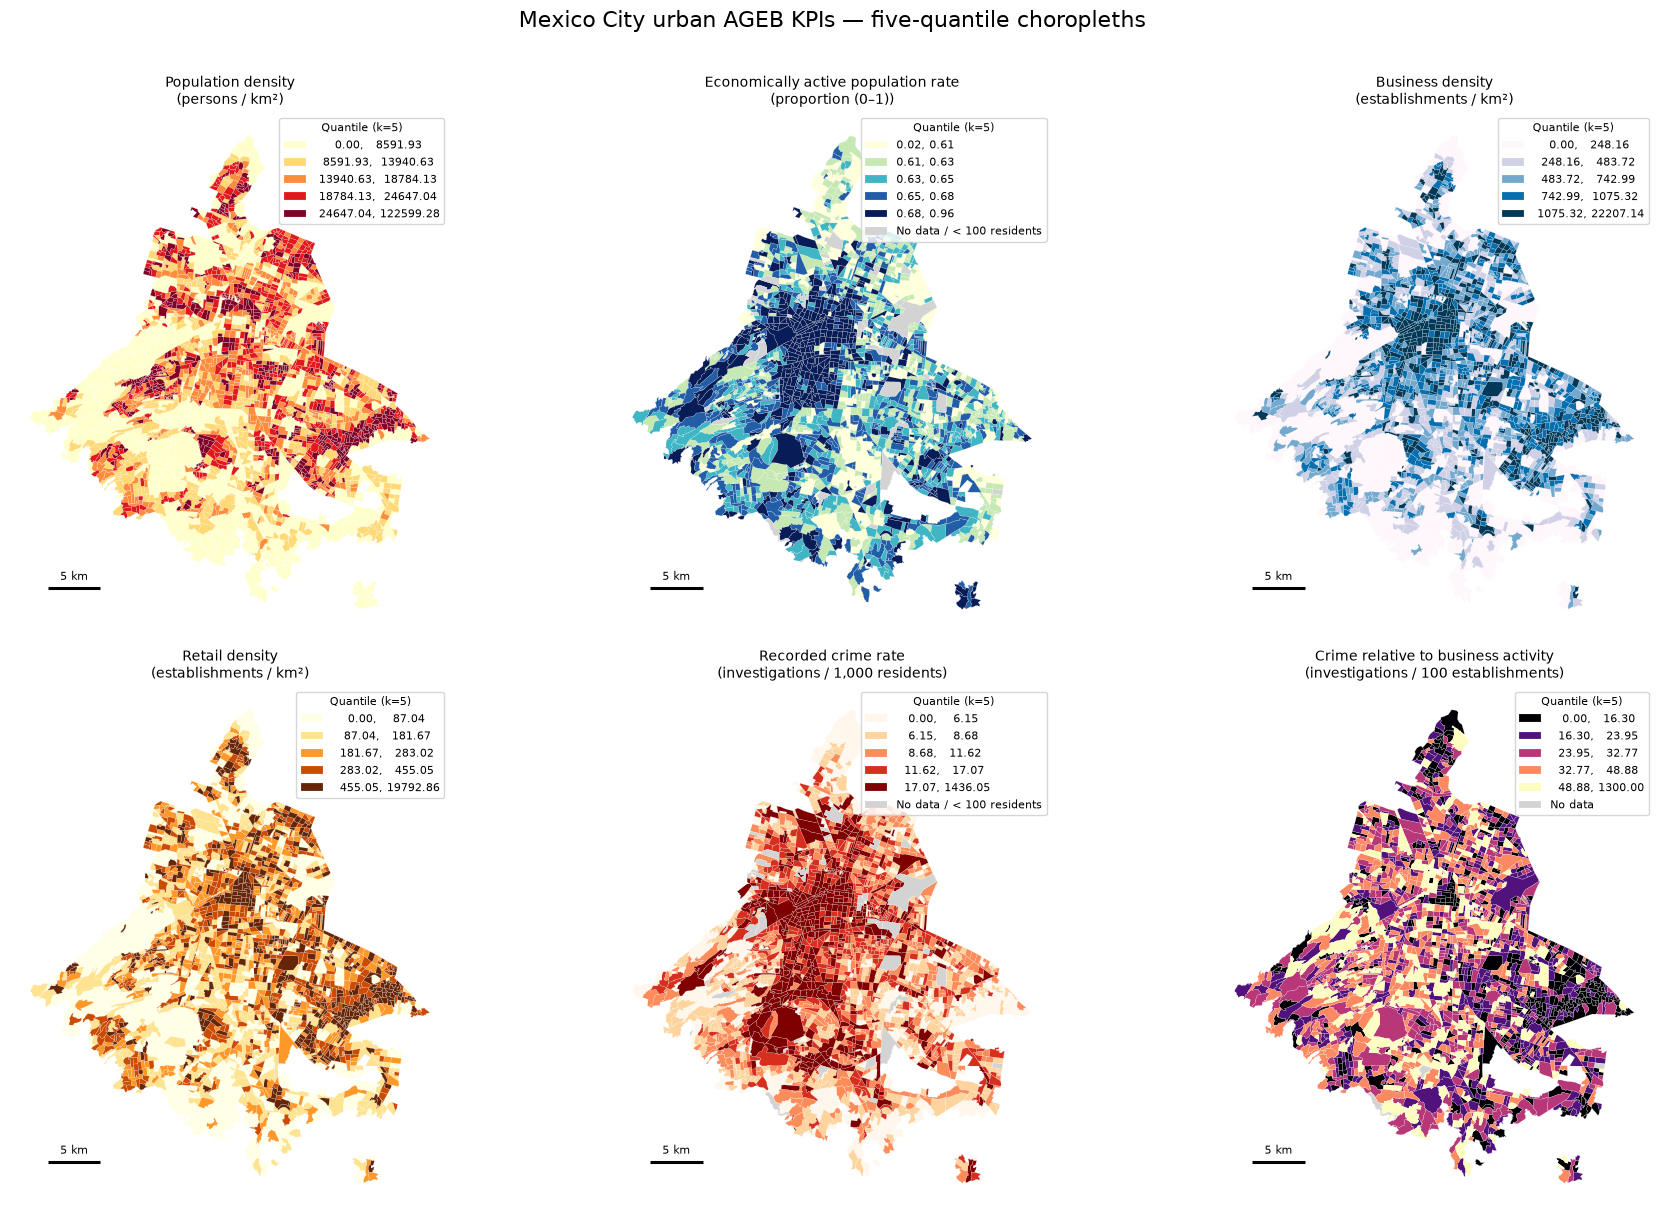

Saved outputs/figures/kpi_choropleths_summary.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
for ax, spec in zip(axes.flat, map_specs):
    draw_choropleth(ax, kpis, spec)
fig.suptitle("Mexico City urban AGEB KPIs — five-quantile choropleths", fontsize=16, y=1.01)
fig.tight_layout()
summary_path = figures_dir / "kpi_choropleths_summary.png"
fig.savefig(summary_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {summary_path.relative_to(PROJECT_ROOT).as_posix()}")